# Dementia Prediction

## Data Loading

In [1]:
# Importing dataset via kaggle

!kaggle datasets download -d shashwatwork/dementia-prediction-dataset

Dataset URL: https://www.kaggle.com/datasets/shashwatwork/dementia-prediction-dataset
License(s): Attribution-NonCommercial-ShareAlike 3.0 IGO (CC BY-NC-SA 3.0 IGO)
  0%|                                               | 0.00/6.74k [00:00<?, ?B/s]
100%|██████████████████████████████████████| 6.74k/6.74k [00:00<00:00, 28.3MB/s]


In [2]:
# Exporting dataset from zipfile

import zipfile
zip_ref = zipfile.ZipFile('/home/bhxveshhh/ML/Dementia Prediction/dementia-prediction-dataset.zip', 'r')
zip_ref.extractall('/home/bhxveshhh/ML/Dementia Prediction')
zip_ref.close()

## Explortory Data Analysis

In [31]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [32]:
df = pd.read_csv('dementia_dataset.csv')

In [5]:
df.head()

,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,OAS2_0001,OAS2_0001_MR1,Nondemented,1,0,M,R,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,OAS2_0001,OAS2_0001_MR2,Nondemented,2,457,M,R,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,OAS2_0002,OAS2_0002_MR1,Demented,1,0,M,R,75,12,NaN,23.0,0.5,1678,0.736,1.046
3,OAS2_0002,OAS2_0002_MR2,Demented,2,560,M,R,76,12,NaN,28.0,0.5,1738,0.713,1.010
4,OAS2_0002,OAS2_0002_MR3,Demented,3,1895,M,R,80,12,NaN,22.0,0.5,1698,0.701,1.034


In [6]:
df.shape

(373, 15)

In [7]:
df.size

5595

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 373 entries, 0 to 372
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Subject ID  373 non-null    object 
 1   MRI ID      373 non-null    object 
 2   Group       373 non-null    object 
 3   Visit       373 non-null    int64  
 4   MR Delay    373 non-null    int64  
 5   M/F         373 non-null    object 
 6   Hand        373 non-null    object 
 7   Age         373 non-null    int64  
 8   EDUC        373 non-null    int64  
 9   SES         354 non-null    float64
 10  MMSE        371 non-null    float64
 11  CDR         373 non-null    float64
 12  eTIV        373 non-null    int64  
 13  nWBV        373 non-null    float64
 14  ASF         373 non-null    float64
dtypes: float64(5), int64(5), object(5)
memory usage: 43.8+ KB


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Visit,373.0,1.882038,0.922843,1.000,1.000,2.000,2.000,5.000
MR Delay,373.0,595.104558,635.485118,0.000,0.000,552.000,873.000,2639.000
Age,373.0,77.013405,7.640957,60.000,71.000,77.000,82.000,98.000
EDUC,373.0,14.597855,2.876339,6.000,12.000,15.000,16.000,23.000
SES,354.0,2.460452,1.134005,1.000,2.000,2.000,3.000,5.000
MMSE,371.0,27.342318,3.683244,4.000,27.000,29.000,30.000,30.000
CDR,373.0,0.290885,0.374557,0.000,0.000,0.000,0.500,2.000
eTIV,373.0,1488.128686,176.139286,1106.000,1357.000,1470.000,1597.000,2004.000
nWBV,373.0,0.729568,0.037135,0.644,0.700,0.729,0.756,0.837
ASF,373.0,1.195461,0.138092,0.876,1.099,1.194,1.293,1.587


In [10]:
df.isnull().sum()

Subject ID     0
MRI ID         0
Group          0
Visit          0
MR Delay       0
M/F            0
Hand           0
Age            0
EDUC           0
SES           19
MMSE           2
CDR            0
eTIV           0
nWBV           0
ASF            0
dtype: int64

In [11]:
df.nunique()

Subject ID    150
MRI ID        373
Group           3
Visit           5
MR Delay      201
M/F             2
Hand            1
Age            39
EDUC           12
SES             5
MMSE           18
CDR             4
eTIV          286
nWBV          136
ASF           265
dtype: int64

## Data Visualization

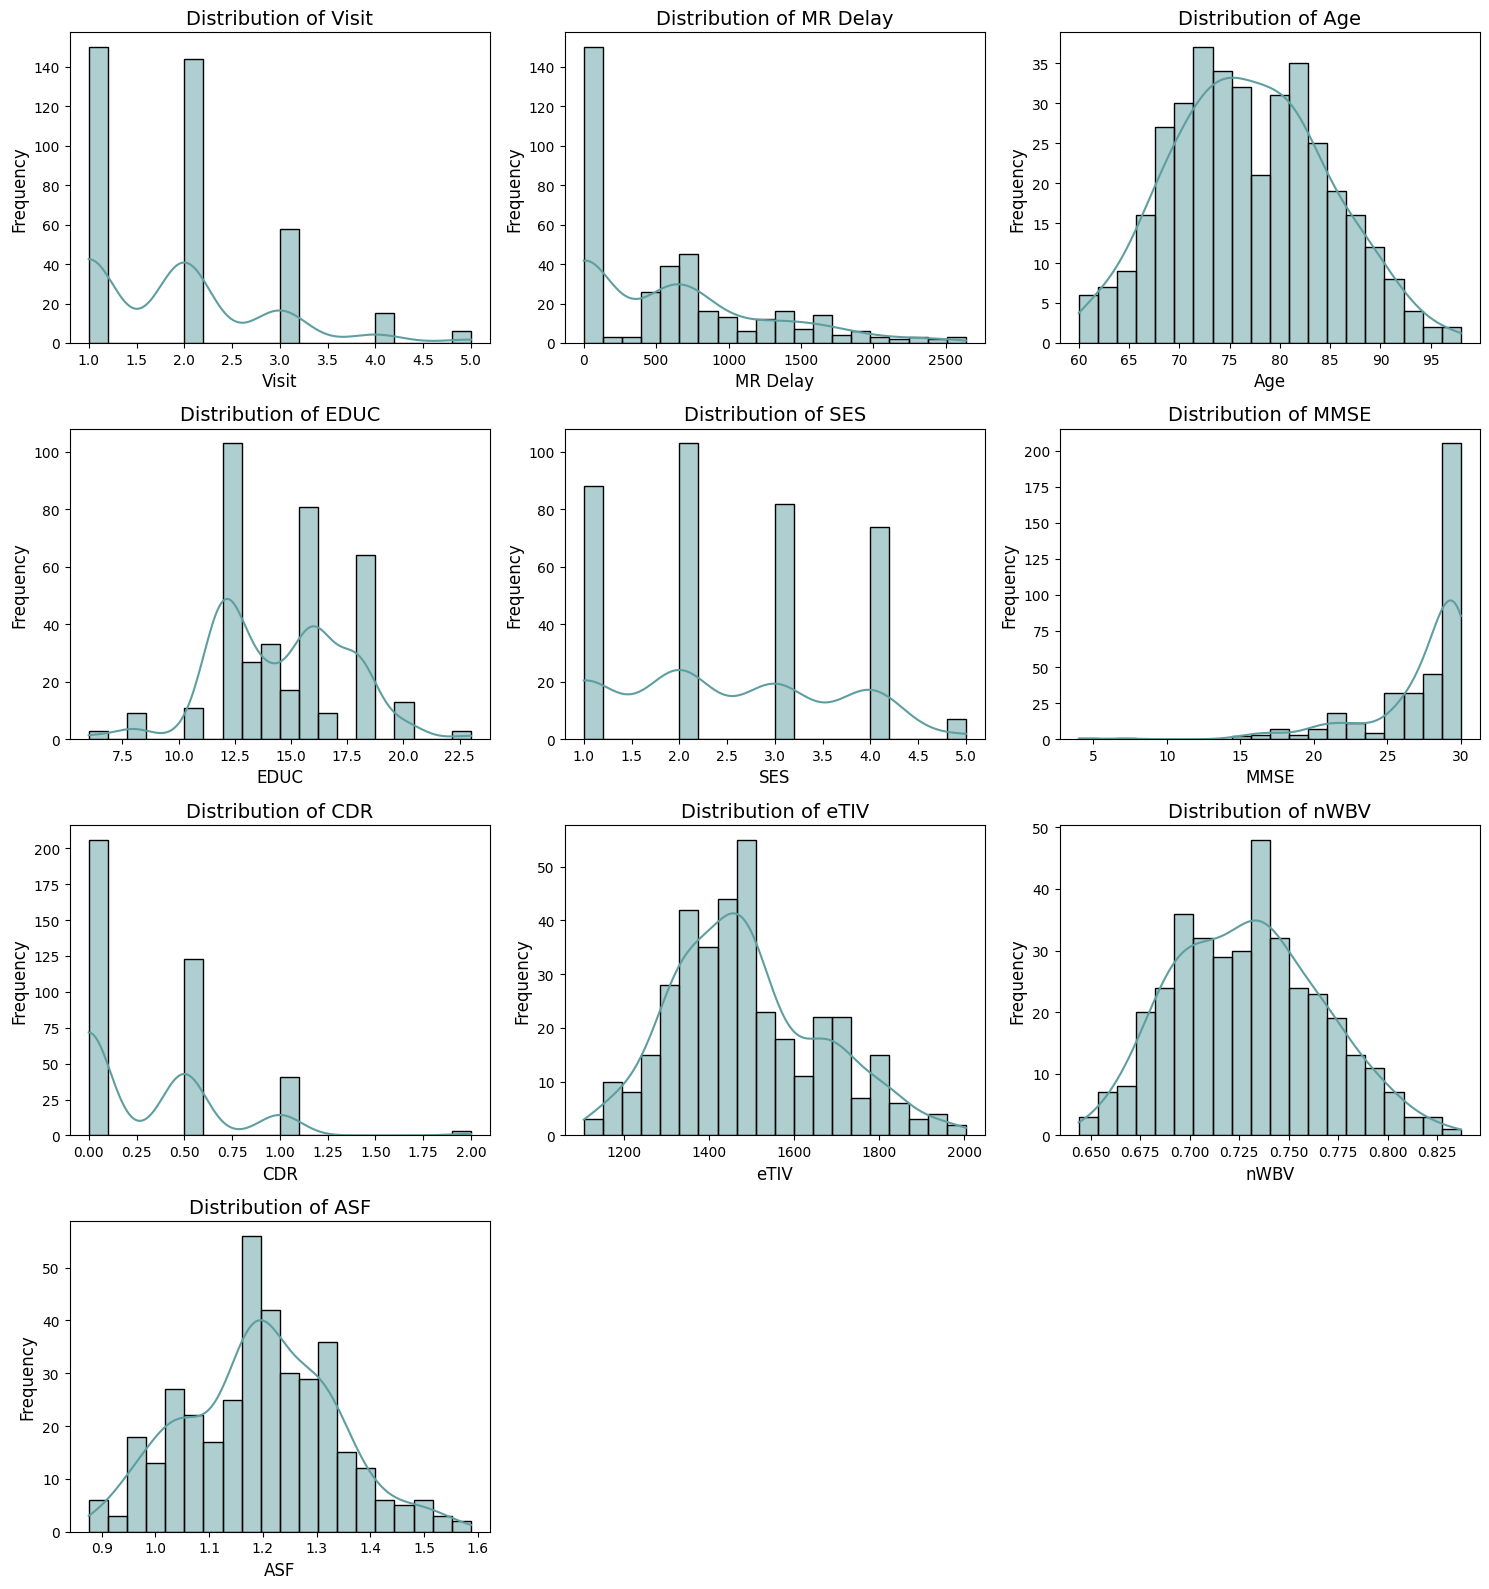

In [33]:
# Histograms for numerical columns

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns


num_cols = len(numerical_cols)
rows = int(np.ceil(num_cols / 3))  
cols = min(3, num_cols)  
fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
axes = axes.flatten()  

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], bins=20, kde=True, color="cadetblue", edgecolor="black", ax=axes[i])
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel("Frequency", fontsize=12)
    axes[i].set_title(f"Distribution of {col}", fontsize=14)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

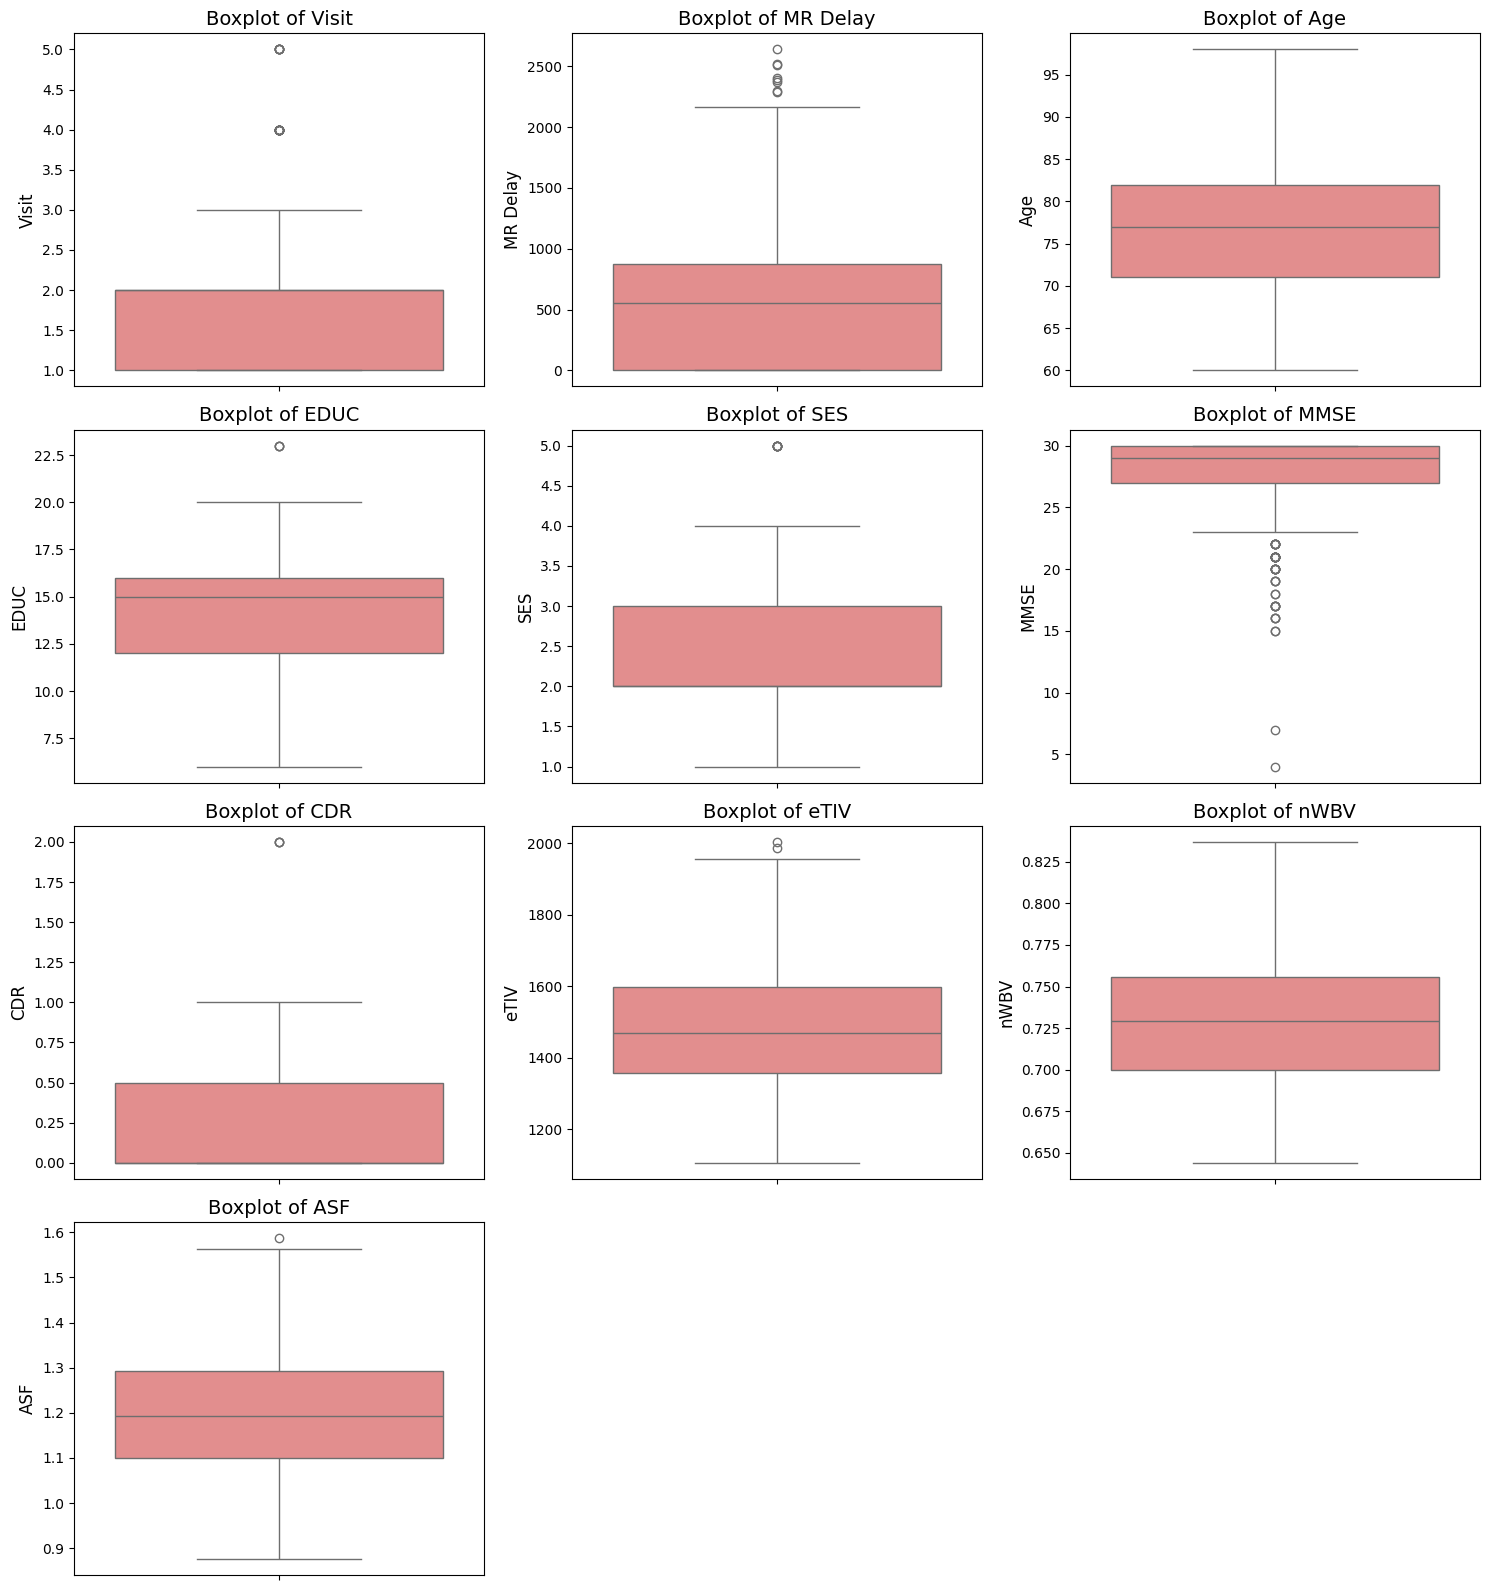

In [34]:
# Plotting each numerical column as a boxplot

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

num_cols = len(numerical_cols)
rows = int(np.ceil(num_cols / 3))  
cols = min(3, num_cols)  
fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
axes = axes.flatten() 

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], color="lightcoral", ax=axes[i])
    axes[i].set_ylabel(col, fontsize=12)
    axes[i].set_title(f"Boxplot of {col}", fontsize=14)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

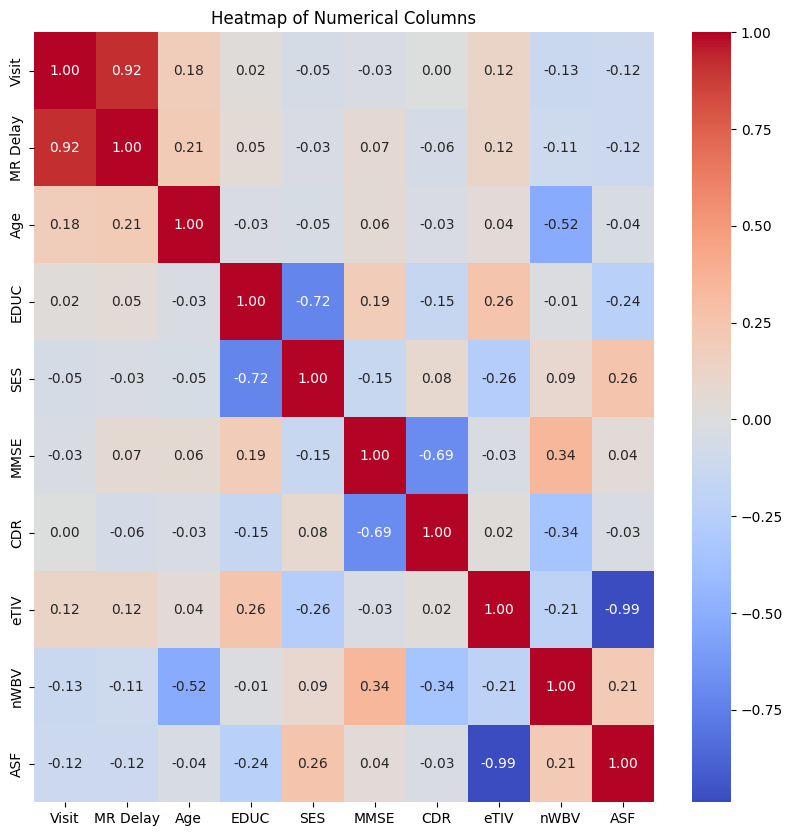

In [36]:
# Heatmap for numerical columns

numerical_columns = df.select_dtypes(include=['number'])

plt.figure(figsize=(10, 10))
sns.heatmap(numerical_columns.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap of Numerical Columns')
plt.show()

## Data Preprocessing

In [13]:
# Renaming columns for better understanding

df.rename ( columns = { 'Group': 'Dementia'}, inplace=True ) 
df.rename ( columns = { 'M/F': 'Sex'}, inplace=True ) 

In [ ]:
# Dropping unwanted column

df.drop(columns=['Subject ID', 'MRI ID'], inplace=True) 
df.drop(columns=['Hand'], inplace=True)

In [21]:
# Filling null values

# Impute mode for categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns
df[categorical_columns] = df[categorical_columns].fillna(df[categorical_columns].mode().iloc[0])

# Impute mean for numeric columns
numeric_columns = df.select_dtypes(include=['number']).columns
df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].mean())

In [22]:
# Label encoding

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
for col in df.columns:
    df[col] = encoder.fit_transform(df[col].values)

In [23]:
X = df.drop(columns=['Dementia'])
y = df['Dementia']

In [24]:
# Train test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
# SMOTE

from imblearn.over_sampling import SMOTE

smt = SMOTE ()
X_train, y_train = smt.fit_resample (X_train, y_train)

In [26]:
# Standard Scaler

from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
X_train_std = std_scaler.fit_transform ( X_train )
X_test_std = std_scaler.transform ( X_test )

## Model Building

In [27]:
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [28]:
logistic_clf = LogisticRegression()
ridge_clf = RidgeClassifier()
xgboost_clf = XGBClassifier()
random_forest_clf = RandomForestClassifier()
ada_boost_clf = AdaBoostClassifier()
grad_boost_clf = GradientBoostingClassifier()
bagging_clf = BaggingClassifier()
decision_tree_clf = DecisionTreeClassifier()
svm_clf = SVC()

In [29]:
model_li = [logistic_clf, ridge_clf, xgboost_clf, random_forest_clf, 
            ada_boost_clf, grad_boost_clf, bagging_clf, decision_tree_clf, svm_clf]

scores = []
for model in model_li:
    model.fit(X_train_std, y_train)
    scores.append(accuracy_score(y_test, model.predict(X_test_std)))

print(scores)

[0.84, 0.8933333333333333, 0.8533333333333334, 0.8666666666666667, 0.72, 0.8666666666666667, 0.8533333333333334, 0.8133333333333334, 0.8533333333333334]


## Model Evaluation

Model: LogisticRegression
Classification Report:
               precision    recall  f1-score   support

           0       0.36      0.36      0.36        11
           1       0.90      0.84      0.87        32
           2       0.76      0.81      0.79        32

    accuracy                           0.76        75
   macro avg       0.68      0.67      0.67        75
weighted avg       0.76      0.76      0.76        75

Confusion Matrix:
 [[ 4  0  7]
 [ 4 27  1]
 [ 3  3 26]]


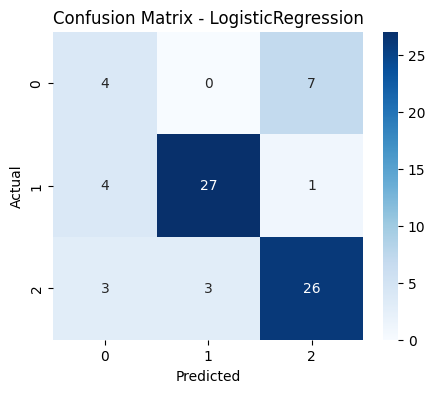

Model: RidgeClassifier
Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.64      0.61        11
           1       0.97      0.91      0.94        32
           2       0.85      0.88      0.86        32

    accuracy                           0.85        75
   macro avg       0.80      0.81      0.80        75
weighted avg       0.86      0.85      0.86        75

Confusion Matrix:
 [[ 7  0  4]
 [ 2 29  1]
 [ 3  1 28]]


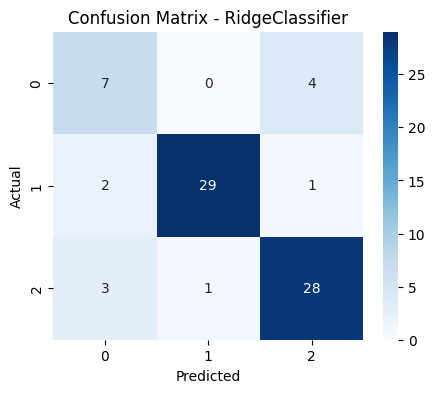

Model: XGBClassifier
Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.27      0.38        11
           1       0.91      0.97      0.94        32
           2       0.83      0.94      0.88        32

    accuracy                           0.85        75
   macro avg       0.78      0.73      0.73        75
weighted avg       0.83      0.85      0.83        75

Confusion Matrix:
 [[ 3  2  6]
 [ 1 31  0]
 [ 1  1 30]]


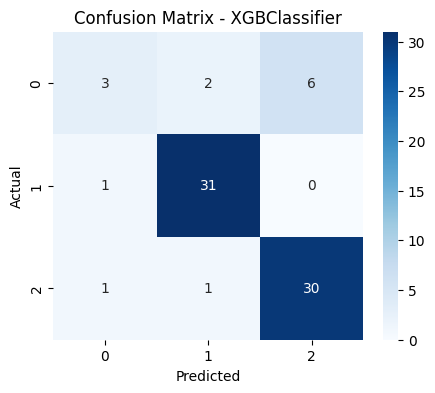

Model: RandomForestClassifier
Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.45      0.56        11
           1       0.94      0.97      0.95        32
           2       0.86      0.94      0.90        32

    accuracy                           0.88        75
   macro avg       0.84      0.79      0.80        75
weighted avg       0.87      0.88      0.87        75

Confusion Matrix:
 [[ 5  1  5]
 [ 1 31  0]
 [ 1  1 30]]


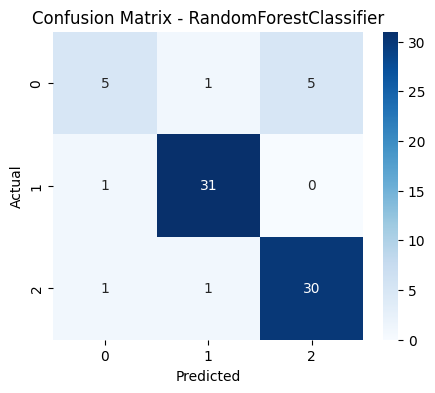

Model: AdaBoostClassifier
Classification Report:
               precision    recall  f1-score   support

           0       0.26      0.45      0.33        11
           1       0.94      0.91      0.92        32
           2       0.80      0.62      0.70        32

    accuracy                           0.72        75
   macro avg       0.67      0.66      0.65        75
weighted avg       0.78      0.72      0.74        75

Confusion Matrix:
 [[ 5  1  5]
 [ 3 29  0]
 [11  1 20]]


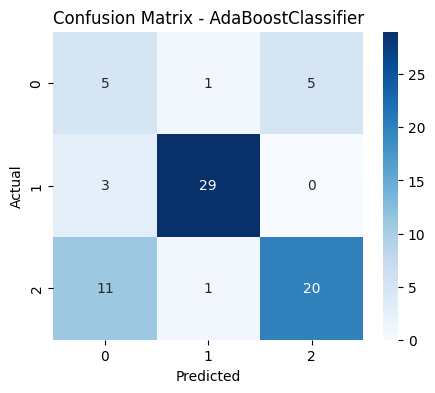

Model: GradientBoostingClassifier
Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.36      0.47        11
           1       0.94      0.97      0.95        32
           2       0.83      0.94      0.88        32

    accuracy                           0.87        75
   macro avg       0.81      0.76      0.77        75
weighted avg       0.85      0.87      0.85        75

Confusion Matrix:
 [[ 4  1  6]
 [ 1 31  0]
 [ 1  1 30]]


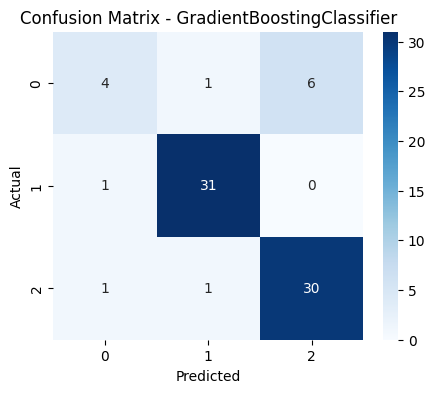

Model: BaggingClassifier
Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.36      0.44        11
           1       0.94      0.97      0.95        32
           2       0.83      0.91      0.87        32

    accuracy                           0.85        75
   macro avg       0.78      0.75      0.75        75
weighted avg       0.84      0.85      0.84        75

Confusion Matrix:
 [[ 4  1  6]
 [ 1 31  0]
 [ 2  1 29]]


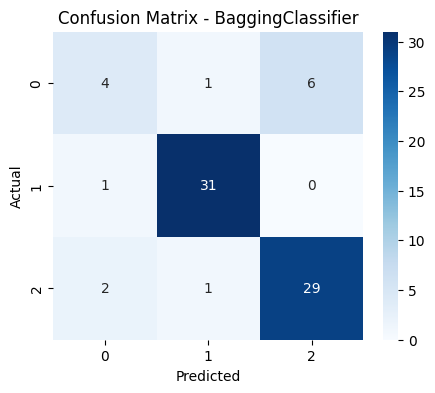

Model: DecisionTreeClassifier
Classification Report:
               precision    recall  f1-score   support

           0       0.43      0.55      0.48        11
           1       0.93      0.88      0.90        32
           2       0.87      0.84      0.86        32

    accuracy                           0.81        75
   macro avg       0.74      0.75      0.75        75
weighted avg       0.83      0.81      0.82        75

Confusion Matrix:
 [[ 6  1  4]
 [ 4 28  0]
 [ 4  1 27]]


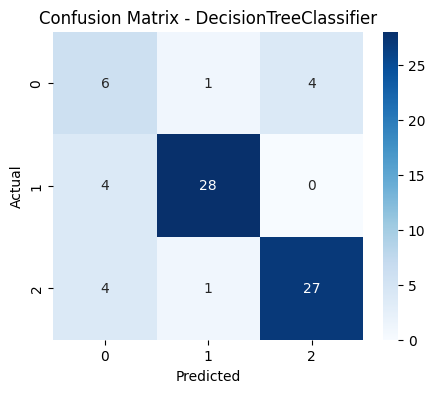

Model: SVC
Classification Report:
               precision    recall  f1-score   support

           0       0.19      0.36      0.25        11
           1       0.59      0.53      0.56        32
           2       0.56      0.44      0.49        32

    accuracy                           0.47        75
   macro avg       0.45      0.44      0.43        75
weighted avg       0.52      0.47      0.48        75

Confusion Matrix:
 [[ 4  3  4]
 [ 8 17  7]
 [ 9  9 14]]


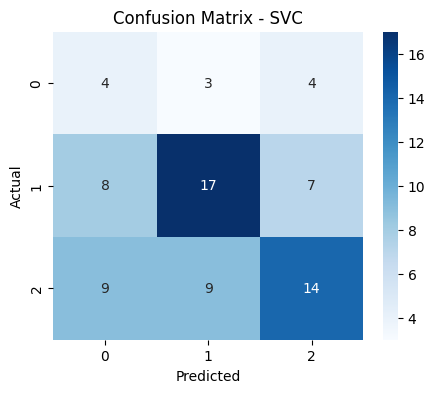

In [30]:
for model in model_li:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"Model: {model.__class__.__name__}")
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

    # Plot the confusion matrix
    plt.figure(figsize=(5, 4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {model.__class__.__name__}")
    plt.show()